In [1]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


In [2]:
# Step 2: Create a simple dataset (20 samples, 2 features)
data = pd.DataFrame({
    'Income': [25,27,29,31,33,35,37,39,41,43,60,62,64,66,68,70,72,74,76,78],
    'Spending_Score': [80,78,75,72,70,65,60,58,55,52,48,45,43,40,38,35,33,30,28,25]
})

In [3]:
print("Dataset:")
print(data)

Dataset:
    Income  Spending_Score
0       25              80
1       27              78
2       29              75
3       31              72
4       33              70
5       35              65
6       37              60
7       39              58
8       41              55
9       43              52
10      60              48
11      62              45
12      64              43
13      66              40
14      68              38
15      70              35
16      72              33
17      74              30
18      76              28
19      78              25


In [4]:
# Step 3: Standardize the data (important for distance-based clustering)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [5]:
# Step 4: Generate linkage matrix for dendrogram
linked = linkage(scaled_data, method='ward')

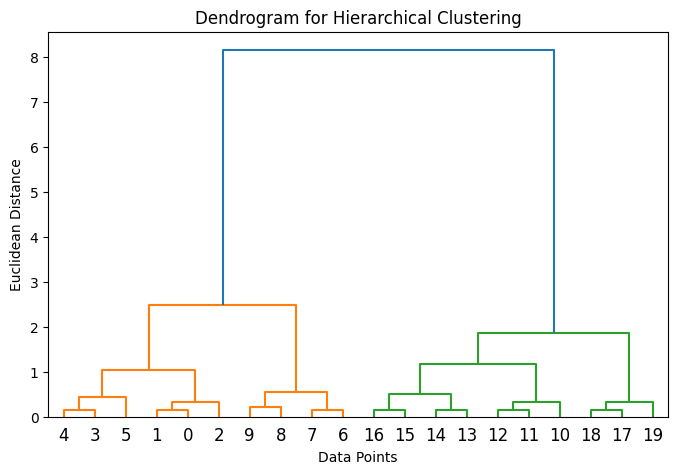

In [6]:
# Step 5: Plot dendrogram
plt.figure(figsize=(8,5))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()

In [7]:
# Step 6: Apply Agglomerative Clustering
# (Choose number of clusters based on dendrogram)
cluster = AgglomerativeClustering(n_clusters=3, linkage='ward', metric='euclidean')
data['Cluster'] = cluster.fit_predict(scaled_data)

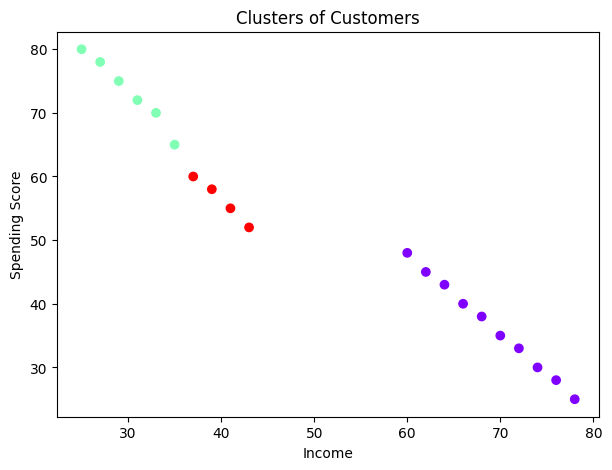

In [8]:
# Step 7: Visualize clusters
plt.figure(figsize=(7,5))
plt.scatter(data['Income'], data['Spending_Score'], c=data['Cluster'], cmap='rainbow')
plt.title('Clusters of Customers')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.show()

In [9]:
# Step 8: Display clustered data
print("\nClustered Data:")
print(data)


Clustered Data:
    Income  Spending_Score  Cluster
0       25              80        1
1       27              78        1
2       29              75        1
3       31              72        1
4       33              70        1
5       35              65        1
6       37              60        2
7       39              58        2
8       41              55        2
9       43              52        2
10      60              48        0
11      62              45        0
12      64              43        0
13      66              40        0
14      68              38        0
15      70              35        0
16      72              33        0
17      74              30        0
18      76              28        0
19      78              25        0
